In [226]:
def add(a:int,b:int)->int:
    """Add a and b.
    
        Args:
            a: first int
            b: second int
        """
    return a+b

In [227]:
add(5,4)

9

In [228]:
add(5.2,4)

9.2

In [229]:
from ensure import ensure_annotations

In [230]:
@ensure_annotations
def add1(a:int,b:int)->int:
    return a+b

In [231]:
#add(3.2,4)

In [232]:
def mul(a:int,b:int)->int:
    """
    Multiply a and b
    
    Args:
    a is int
    b is int
    """
    return a*b

In [233]:
mul(4,5)

20

In [234]:
from typing_extensions import TypedDict

In [235]:
from langgraph.graph import START, END

In [236]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [237]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [238]:
from langchain_groq import ChatGroq

In [239]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [240]:
llm.invoke("Hey").content

'Hey there! 👋 How can I help you today?'

In [241]:
llm_tool=llm.bind_tools([add,mul])

In [242]:
result=llm_tool.invoke("multiply 2 and 4")

In [243]:
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call function mul.', 'tool_calls': [{'id': 'fc_3acc924f-1f3a-472b-87e9-45dfd239927f', 'function': {'arguments': '{"a":2,"b":4}', 'name': 'mul'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 156, 'total_tokens': 190, 'completion_time': 0.035203014, 'completion_tokens_details': {'reasoning_tokens': 8}, 'prompt_time': 0.007596433, 'prompt_tokens_details': None, 'queue_time': 0.281520376, 'total_time': 0.042799447}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_37c9245f64', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02f38-239f-73f1-9704-d66414838aba-0', tool_calls=[{'name': 'mul', 'args': {'a': 2, 'b': 4}, 'id': 'fc_3acc924f-1f3a-472b-87e9-45dfd239927f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 156, 'output_tokens': 34, 'total_tokens':

In [244]:
result.tool_calls

[{'name': 'mul',
  'args': {'a': 2, 'b': 4},
  'id': 'fc_3acc924f-1f3a-472b-87e9-45dfd239927f',
  'type': 'tool_call'}]

In [245]:
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, END, StateGraph

In [246]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [247]:
def llm_output(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [248]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [ ]:
from langgraph.graph import StateGraph
builder=StateGraph(State)
builder.add_node("CHatBot",llm_output)

builder.add_node("tools",ToolNode([add,mul]))


builder.add_edge(START,"CHatBot")
builder.add_conditional_edges("CHatBot",tools_condition)
builder.add_edge("CHatBot",END)
builder.add_edge("tools",END)


graph=builder.compile()



NameError: name 'fools_condition' is not defined

In [250]:
from IPython.display import display, Image

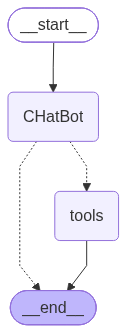

In [251]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [252]:
graph.invoke({"messages":"hey"})

{'messages': [HumanMessage(content='hey', additional_kwargs={}, response_metadata={}, id='4eab8363-a1fd-4322-8418-800c5a8caab6'),
  AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hey". It\'s a greeting. We should respond politely. The system says "You are ChatGPT". We should respond. The user hasn\'t asked a question. We can respond with a friendly greeting and ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 72, 'total_tokens': 143, 'completion_time': 0.07366437, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.003448215, 'prompt_tokens_details': None, 'queue_time': 0.304867073, 'total_time': 0.077112585}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02f38-3349-7c23-8503-d93c1af9127e-0', tool_calls=[],

In [253]:
from langchain_core.messages import HumanMessage, AIMessage

In [254]:
messages=graph.invoke({"messages":HumanMessage(content="What is 2 multiply 3")})

In [255]:
messages["messages"][-1].content

'2\u202f×\u202f3\u202f=\u202f6'

In [256]:
State["messages"]

__main__.State['messages']

In [257]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [HumanMessage(content="What is AI?")]
})

print(result["messages"][-1].content)

**AI = Artificial Intelligence**

At its core, AI is the field of computer science that builds systems capable of performing tasks that normally require human intelligence. Those tasks include:

| What humans do | What AI can do |
|----------------|----------------|
| **Perceiving** (seeing, hearing, sensing) | Image, speech, and sensor‑based perception |
| **Thinking** (reasoning, planning, problem‑solving) | Symbolic reasoning, probabilistic inference, optimization |
| **Learning** (acquiring knowledge, improving over time) | Machine learning, deep learning, reinforcement learning |
| **Acting** (moving, manipulating objects) | Robotics, autonomous vehicles, game agents |
| **Communicating** (understanding and producing language) | Natural‑language processing, chatbots, translation |

### How it works

1. **Data + Algorithms** – AI systems learn from large datasets using mathematical models (neural networks, decision trees, etc.).
2. **Training** – The model adjusts its internal para

In [258]:
def llm_tool_output(state:State):
    return {"messages":[llm_tool.invoke(state["messages"])]}

In [259]:
from langgraph.graph import StateGraph
builder=StateGraph(State)
builder.add_node("CHatBot",llm_tool_output)


builder.add_edge(START,"CHatBot")


builder.add_edge("CHatBot",END)

graph=builder.compile()


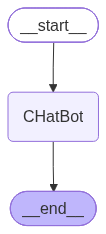

In [260]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [261]:
result=graph.invoke({"messages":HumanMessage(content="Hey")})

In [262]:
result["messages"][-1].content

'Hey there! 👋 How can I help you today?'

In [263]:
llm_tool.invoke("multiply 2 and 4")

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the function mul with a=2, b=4.', 'tool_calls': [{'id': 'fc_b54fb28c-332f-4fcb-922b-eb9026de40c1', 'function': {'arguments': '{"a":2,"b":4}', 'name': 'mul'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 156, 'total_tokens': 199, 'completion_time': 0.049898717, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.007764233, 'prompt_tokens_details': None, 'queue_time': 0.281127559, 'total_time': 0.05766295}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02f38-406a-7501-bb82-b95f40d1e525-0', tool_calls=[{'name': 'mul', 'args': {'a': 2, 'b': 4}, 'id': 'fc_b54fb28c-332f-4fcb-922b-eb9026de40c1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 156, 'output_tokens': 4

In [264]:
result=graph.invoke({"messages":HumanMessage(content="multiply 2 and 4")})

In [265]:
messages=graph.invoke({"messages":HumanMessage(content="What is 2 multiply 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply 3
================================== Ai Message ==================================
Tool Calls:
  mul (fc_001cd4e4-f6e8-4d3f-9d6e-06bc2e8e3ab7)
 Call ID: fc_001cd4e4-f6e8-4d3f-9d6e-06bc2e8e3ab7
  Args:
    a: 2
    b: 3
